In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
TARGET_BAKERY = '19 квартал 8/1 Казань Куюки'

In [ ]:
df_ = pd.read_csv("C:\\Users\\dns\\Desktop\\Projects\\demand-forecasting-model\\src\\experiments_v2\\71_bakery_total_sales\\predictions_global_lgbm.csv")

In [61]:
df_[df_['Пекарня'] == TARGET_BAKERY]

,Дата,Пекарня,Продано,model,prediction,abs_error
0,2026-03-10,19 квартал 8/1 Казань Куюки,876.5,global_lgbm,1037.776599,161.276599
1,2026-03-11,19 квартал 8/1 Казань Куюки,1150.7,global_lgbm,1072.090391,78.609609
2,2026-03-12,19 квартал 8/1 Казань Куюки,1247.1,global_lgbm,1151.623183,95.476817
3,2026-03-13,19 квартал 8/1 Казань Куюки,1290.5,global_lgbm,1146.431167,144.068833
4,2026-03-14,19 квартал 8/1 Казань Куюки,924.8,global_lgbm,885.604048,39.195952
5,2026-03-15,19 квартал 8/1 Казань Куюки,753.8,global_lgbm,681.166524,72.633476
6,2026-03-16,19 квартал 8/1 Казань Куюки,1294.7,global_lgbm,1102.764173,191.935827
7,2026-03-17,19 квартал 8/1 Казань Куюки,1340.2,global_lgbm,1130.370409,209.829591
8,2026-03-18,19 квартал 8/1 Казань Куюки,1287.7,global_lgbm,1168.668939,119.031061
9,2026-03-19,19 квартал 8/1 Казань Куюки,1415.1,global_lgbm,1245.216224,169.883776


In [ ]:
df_['Дата'] = pd.to_datetime(df_['Дата'], errors="coerce")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plots(target):
    df_[df_['Пекарня'] == target]    
    
    fig, ax = plt.subplots(figsize=(18, 8))

    ax.plot(
        df_[df_['Пекарня'] == target]['Дата'],
        df_[df_['Пекарня'] == target]['Продано'],
        label='Actual daily qty'
    )

    ax.plot(
        df_[df_['Пекарня'] == target]['Дата'],
        df_[df_['Пекарня'] == target]['prediction']*1,
        label='Expected from daily profile'
    )

    ax.set(
        xlabel='Date',
        ylabel='Quantity',
        title=f'Daily quantity comparison {target}'
    )

    # Дневная сетка
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    ax.grid(True, which='major', axis='both')

    ax.legend()

    plt.xticks(rotation=45)

    plt.tight_layout()

    fig.savefig("test.png")

    plt.show()

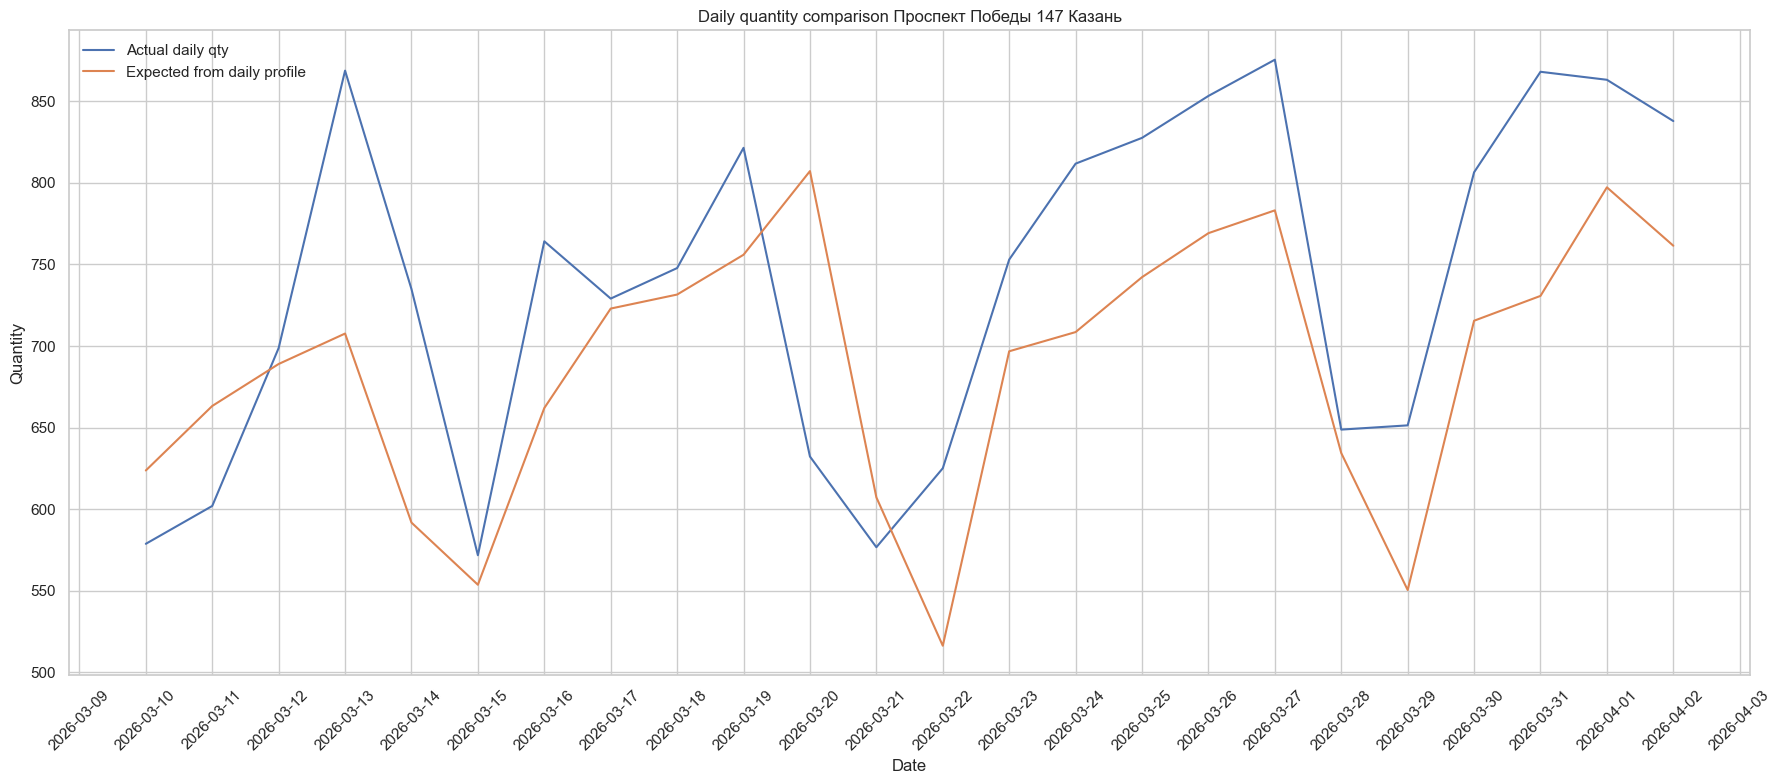

In [ ]:
plots('Хади Такташ 105 Казань')

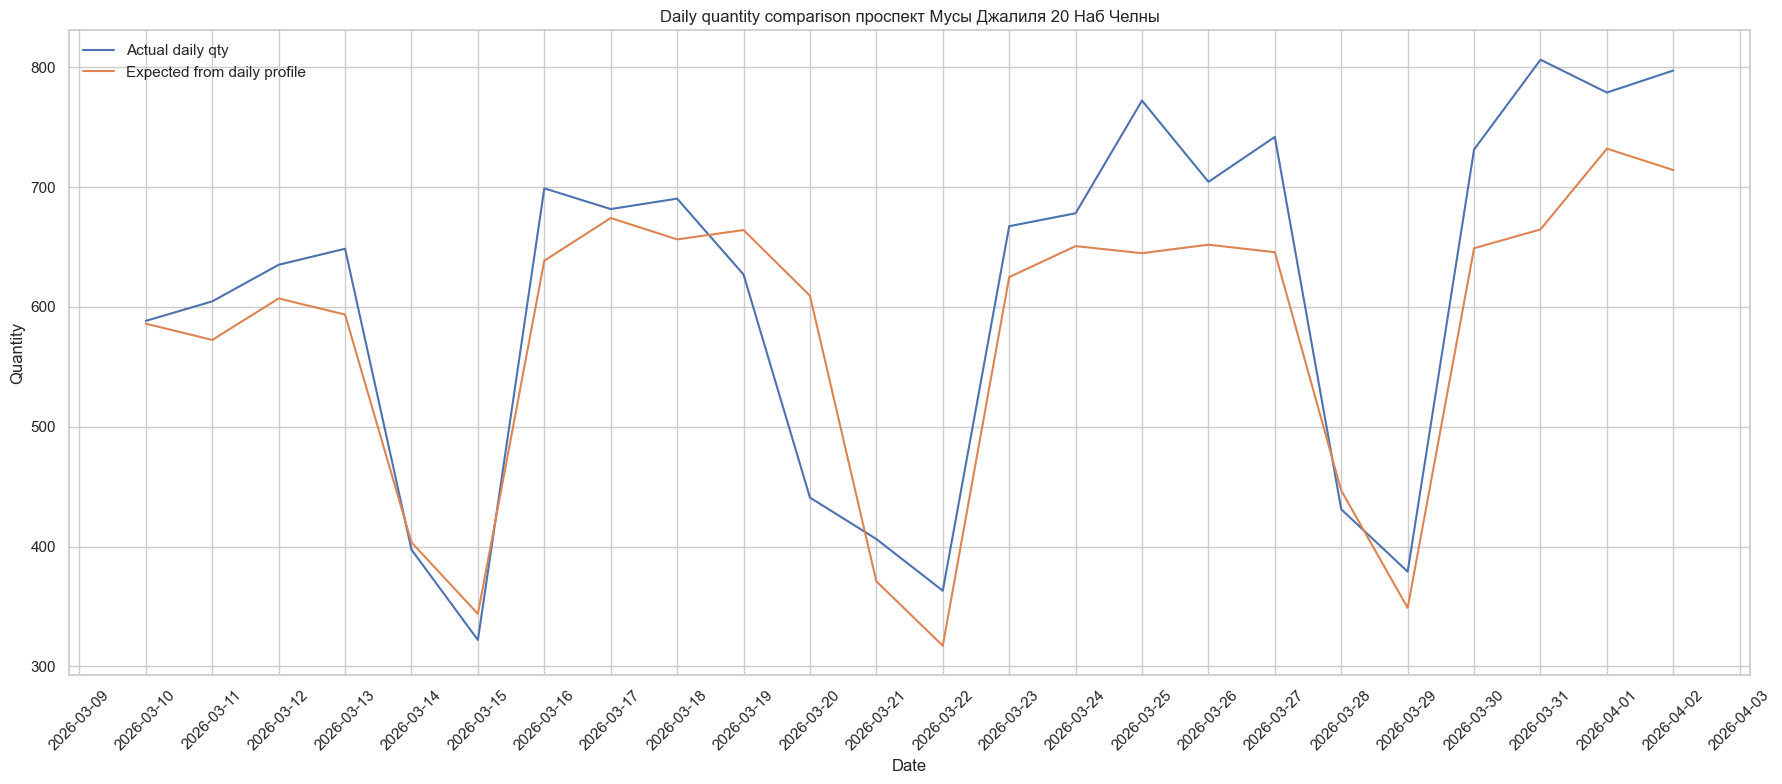

In [254]:
plots(df_['Пекарня'].unique()[180])

In [ ]:
df_['Пекарня'].unique()

array(['19 квартал 8/1 Казань Куюки', '2-я юго-западная 30 Казань',
       'Аббасова 4 Казань', 'Автозаводский Проспект 28/14 Наб Челны',
       'Адоратского 31Б Казань', 'Адоратского 38Д Казань',
       'Азата Аббасова 10 Казань', 'Айдарова 8А корп 1 Казань',
       'Альфии Авзаловой 5 Казань', 'Амирхана 17 Казань',
       'Арсланова 13 Казань', 'Б. Хмельницкого 109/3 Чебоксары',
       'Баки Урманче 6 Казань', 'Баки Урманче 9 Казань',
       'Баумана 29/11 Казань', 'Белинского 1/3 Казань',
       'Белинского 9/6 Казань', 'Беломорская 238 Казань',
       'Беломорская 6 Казань', 'Бигичева 16А Казань',
       'Братьев Батталовых 27 Казань', 'Булатова 1А Казань',
       'Бызова 8 Нижнекамск', 'Вагапова 3 Казань',
       'Вахитова 20 Наб Челны', 'Винокурова 28 Новочебоксарск',
       'Вишневского 8/35 Казань', 'Восстания 117 Казань',
       'Габдуллы Тукая 62А Казань', 'Гаврилова 40 Казань',
       'Гагарина 17 Зеленодольск', 'Гагарина 17Б Чебоксары',
       'Горьковское шоссе 2Ак1 Казань

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.dates import DayLocator, DateFormatter

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

In [270]:
ROOT = Path(r'C:/Users/dns/Desktop/Projects/demand-forecasting-model')
SOURCE_CSV = ROOT / 'data' / 'raw' / 'sales_hrs_all.csv'
MONTH_OUT = ROOT / 'data' / 'processed' / 'sales_hrs_last_full_month.csv'
REPORT_DIR = ROOT / 'reports' / 'monthly_demand_review'

DATE_COL = 'Дата продажи'
DATETIME_COL = 'Дата время чека'
EVENT_COL = 'Вид события по кассе'
BAKERY_COL = 'Касса.Торговая точка'
PRODUCT_COL = 'Номенклатура'
QTY_COL = 'Кол-во'
SALES_EVENT = 'Продажа'

# Fill these manually before running the comparison.
# TARGET_BAKERY = 'Проспект Победы 147 Казань'
TARGET_BAKERY = 'Проспект Победы 147 Казань'
TARGET_PRODUCT = 'Треугольник курица безд'

CHUNK_SIZE = 500_000

In [55]:
df = pd.read_csv('C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/raw/sales_hrs_all.csv')

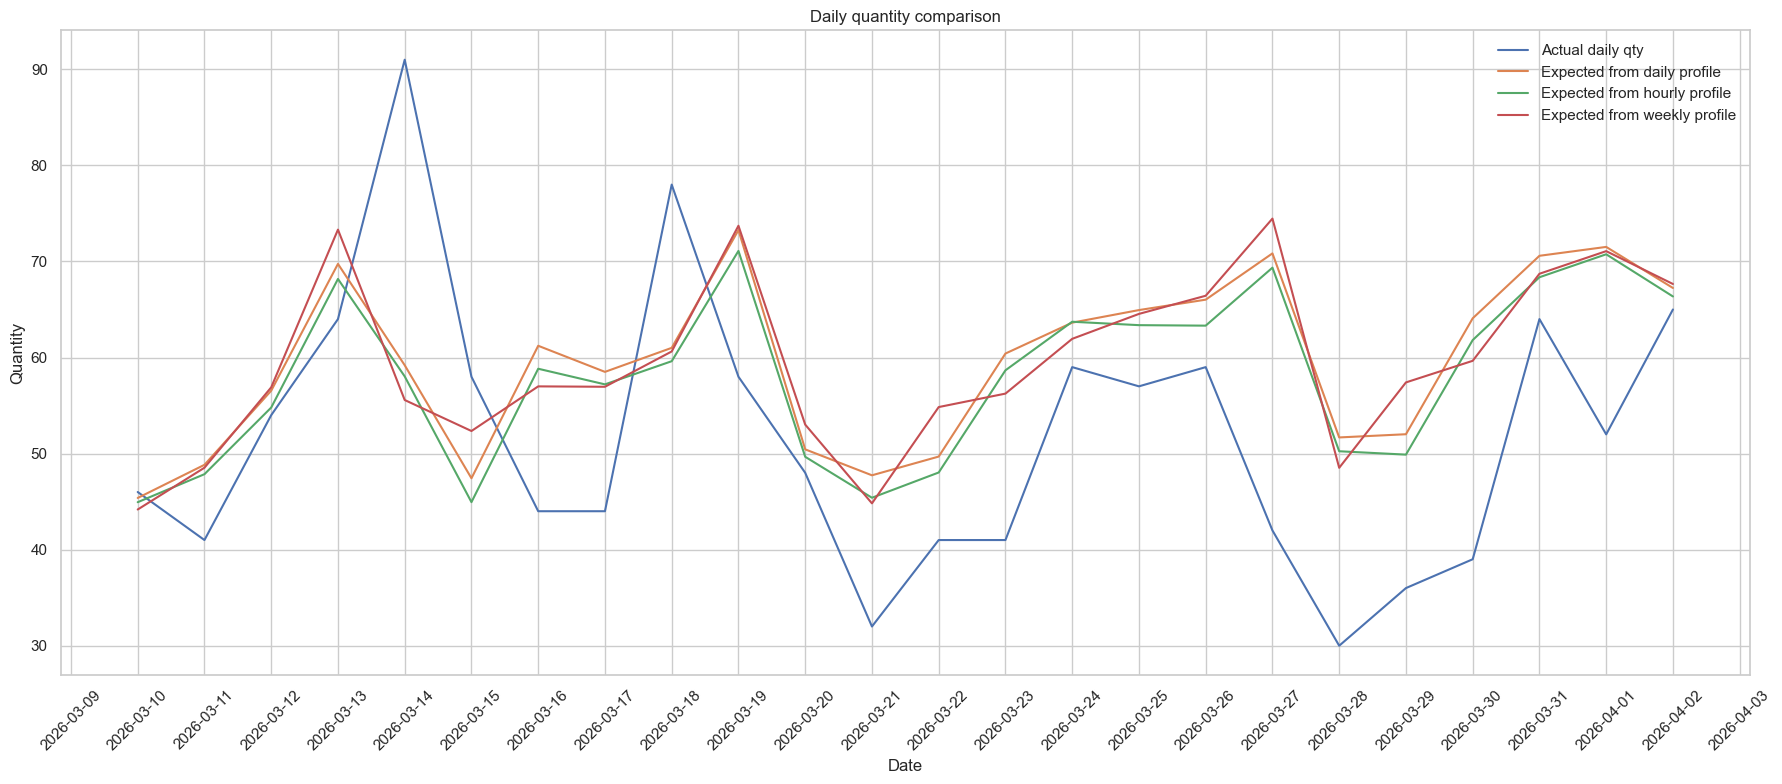

In [271]:
def build_hourly_and_daily_profiles(month_df: pd.DataFrame, bakery: str, product: str):
    bakery_df = month_df[month_df[BAKERY_COL] == bakery].copy()
    if bakery_df.empty:
        raise ValueError(f'Bakery not found in selected month: {bakery}')
    bakery_df["date"] = bakery_df[DATE_COL].dt.normalize()
    bakery_df["hour"] = bakery_df[DATETIME_COL].dt.hour
    product_df = bakery_df[bakery_df[PRODUCT_COL] == product].copy()
    if product_df.empty:
        raise ValueError(f'Product not found for bakery {bakery}: {product}')


#hourly--------------------------------------------------------------------
    bakery_hourly = bakery_df.groupby(["date", "hour"], as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "bakery_hour_qty"})
    product_hourly = product_df.groupby(["date", "hour"], as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "product_hour_qty"})
    hourly = bakery_hourly.merge(product_hourly, on=["date", "hour"], how="left")
    hourly["product_hour_qty"] = hourly["product_hour_qty"].fillna(0.0)
    hourly["hour_share"] = hourly["product_hour_qty"] / hourly["bakery_hour_qty"].where(hourly["bakery_hour_qty"] > 0)

    hourly_profile = (
        hourly.dropna(subset=["hour_share"])
        .groupby("hour", as_index=False)
        .agg(
            avg_hour_share=("hour_share", "mean"),
            n_obs=("hour_share", "count"),
            n_days=("date", "nunique"),
        )
    )
    hourly_profile = pd.DataFrame({"hour": list(range(24))}).merge(hourly_profile, on="hour", how="left")

    hourly = hourly.merge(hourly_profile, on="hour", how="left")
    hourly["expected_hour_qty"] = hourly["bakery_hour_qty"] * hourly["avg_hour_share"]
    daily_from_hourly = (
        hourly.groupby("date", as_index=False)[["bakery_hour_qty", "product_hour_qty", "expected_hour_qty"]]
        .sum()
        .rename(columns={
            "bakery_hour_qty": "bakery_daily_qty",
            "product_hour_qty": "actual_daily_qty_from_hourly",
            "expected_hour_qty": "expected_daily_qty_from_hourly",
        })
    )


# zero_less ---------------------------------------------------------------

    hourly_zero_less = hourly[hourly["product_hour_qty"] > 0].copy()

    hourly_profile_zero_less = (
        hourly_zero_less
        .dropna(subset=["hour_share"])
        .groupby("hour", as_index=False)
        .agg(
            avg_hour_share_zero_less=("hour_share", "mean"),
            n_obs_zero_less=("hour_share", "count"),
            n_days_zero_less=("date", "nunique"),
        )
    )

    hourly_profile_zero_less = (
        pd.DataFrame({"hour": list(range(24))})
        .merge(hourly_profile_zero_less, on="hour", how="left")
    )

    hourly_zero_less = hourly.merge(
        hourly_profile_zero_less,
        on="hour",
        how="left"
    )

    hourly_zero_less["avg_hour_share_zero_less"] = (
        hourly_zero_less["avg_hour_share_zero_less"]
        .fillna(0.0)
    )

    hourly_zero_less["expected_hour_qty_zero_less"] = (
        hourly_zero_less["bakery_hour_qty"] *
        hourly_zero_less["avg_hour_share_zero_less"]
    )

    daily_from_hourly_zero_less = (
        hourly_zero_less
        .groupby("date", as_index=False)[
            [
                "bakery_hour_qty",
                "product_hour_qty",
                "expected_hour_qty_zero_less",
            ]
        ]
        .sum()
        .rename(columns={
            "bakery_hour_qty": "bakery_daily_qty",
            "product_hour_qty": "actual_daily_qty_from_hourly",
            "expected_hour_qty_zero_less": "expected_daily_qty_from_hourly_zero_less",
        })
    )

#weekly--------------------------------------------------------------------
    bakery_daily = bakery_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "bakery_daily_qty"})
    product_daily = product_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "actual_daily_qty"})

    week_daily = bakery_daily.merge(product_daily, on="date", how="left")
    week_daily['weekday'] = week_daily['date'].dt.day_name()
    week_daily["actual_daily_qty"] = week_daily["actual_daily_qty"].fillna(0.0)
    week_daily["daily_share"] = week_daily["actual_daily_qty"] / week_daily["bakery_daily_qty"].where(week_daily["bakery_daily_qty"] > 0)

    weekday_avg_share = (
    week_daily
    .groupby("weekday", as_index=False)["daily_share"]
    .mean()
    .rename(columns={"daily_share": "average_week_daily_share"})
    )
    week_daily = week_daily.merge(weekday_avg_share, on="weekday", how="left")
    week_daily["average_week_daily_share"] = week_daily["average_week_daily_share"].fillna(0.0)


    week_daily["expected_week_daily_qty_from_daily"] = week_daily["bakery_daily_qty"] * week_daily["average_week_daily_share"]
    week_daily["gap_week_daily"] = week_daily["expected_week_daily_qty_from_daily"] - week_daily["actual_daily_qty"]
    week_daily["share_gap"] = week_daily["daily_share"] - week_daily["average_week_daily_share"]

    week_daily = week_daily.merge(daily_from_hourly[["date", "expected_daily_qty_from_hourly"]], on="date", how="left")
    week_daily["gap_hourly"] = week_daily["expected_daily_qty_from_hourly"] - week_daily["actual_daily_qty"]
#daily--------------------------------------------------------------------

    bakery_daily = bakery_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "bakery_daily_qty"})
    product_daily = product_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "actual_daily_qty"})
    daily = bakery_daily.merge(product_daily, on="date", how="left")
    daily["actual_daily_qty"] = daily["actual_daily_qty"].fillna(0.0)
    daily["daily_share"] = daily["actual_daily_qty"] / daily["bakery_daily_qty"].where(daily["bakery_daily_qty"] > 0)

    average_daily_share = daily["daily_share"].dropna().mean()
    if pd.isna(average_daily_share):
        average_daily_share = 0.0
    
    daily["average_daily_share"] = average_daily_share

    daily["expected_daily_qty_from_daily"] = daily["bakery_daily_qty"] * average_daily_share
    daily["gap_daily"] = daily["expected_daily_qty_from_daily"] - daily["actual_daily_qty"]
    daily["share_gap"] = daily["daily_share"] - average_daily_share

    daily = daily.merge(daily_from_hourly[["date", "expected_daily_qty_from_hourly"]], on="date", how="left")
    daily = daily.merge(daily_from_hourly_zero_less[["date", "expected_daily_qty_from_hourly_zero_less"]], on="date", how="left")
    daily["gap_hourly"] = daily["expected_daily_qty_from_hourly"] - daily["actual_daily_qty"]


#q1--------------------------------------------------------------------

    bakery_daily = bakery_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "bakery_daily_qty"})
    product_daily = product_df.groupby("date", as_index=False)[QTY_COL].sum().rename(columns={QTY_COL: "actual_daily_qty"})
    qdaily = bakery_daily.merge(product_daily, on="date", how="left")
    qdaily["actual_daily_qty"] = qdaily["actual_daily_qty"].fillna(0.0)

    qdaily["daily_share"] = qdaily["actual_daily_qty"] / qdaily["bakery_daily_qty"].where(qdaily["bakery_daily_qty"] > 0)

    q10 = daily["daily_share"].quantile(0.2)
    
    filtered = qdaily[qdaily["daily_share"] > q10].copy()

    average_daily_share = filtered["daily_share"].dropna().mean()
    if pd.isna(average_daily_share):
        average_daily_share = 0.0
    
    filtered["average_daily_share"] = average_daily_share

    filtered["expected_daily_qty_from_daily"] = filtered["bakery_daily_qty"] * average_daily_share
    filtered["gap_daily"] = filtered["expected_daily_qty_from_daily"] - filtered["actual_daily_qty"]
    filtered["share_gap"] = filtered["daily_share"] - average_daily_share

    filtered = filtered.merge(daily_from_hourly[["date", "expected_daily_qty_from_hourly"]], on="date", how="left")
    filtered["gap_hourly"] = filtered["expected_daily_qty_from_hourly"] - filtered["actual_daily_qty"]

    return hourly, hourly_profile, daily, week_daily, filtered, hourly_zero_less, average_daily_share

def plot_hourly_and_daily_profiles(daily: pd.DataFrame, hourly_profile: pd.DataFrame, average_daily_share: float, bakery: str, product: str, month_tag: str):
    REPORT_DIR.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(3, 1, figsize=(18, 15), gridspec_kw={"height_ratios": [2, 1, 1]})

    daily_plot = daily.copy()
    daily_plot["date"] = pd.to_datetime(daily_plot["date"])

    axes[0].plot(daily_plot["date"], daily_plot["actual_daily_qty"], label="Actual", linewidth=2, color="black")
    axes[0].plot(daily_plot["date"], daily_plot["expected_daily_qty_from_daily"], label="Expected from daily share", linewidth=2, color="#1f77b4")
    axes[0].plot(daily_plot["date"], daily_plot["expected_daily_qty_from_hourly"], label="Expected from hourly profile", linewidth=2, color="#d62728")
    axes[0].set_title(f"{bakery} / {product} - actual vs both expected series")
    axes[0].legend()
    axes[0].grid(True, which="major", axis="x", linestyle="--", alpha=0.5)
    axes[0].grid(True, which="major", axis="y", alpha=0.3)
    axes[0].xaxis.set_major_locator(DayLocator(interval=1))
    axes[0].xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
    axes[0].tick_params(axis="x", rotation=45)

    hourly_plot = hourly_profile.sort_values("hour")
    axes[1].plot(hourly_plot["hour"], hourly_plot["avg_hour_share"], marker="o", linewidth=2, color="#d95f02")
    axes[1].set_title("Average hourly share in bakery flow")
    axes[1].set_xticks(list(range(24)))
    axes[1].set_xticklabels([f"{h:02d}:00" for h in range(24)])
    axes[1].grid(True, axis="y", alpha=0.3)

    axes[2].plot(daily_plot["date"], daily_plot["daily_share"], marker="o", linewidth=1.5, color="#2ca02c", label="Daily share")
    axes[2].axhline(average_daily_share, color="#1f77b4", linestyle="--", linewidth=2, label=f"Average daily share = {average_daily_share:.4f}")
    axes[2].set_title("Daily share of product in bakery sales")
    axes[2].set_ylabel("Share")
    axes[2].legend()
    axes[2].grid(True, axis="y", alpha=0.3)
    axes[2].xaxis.set_major_locator(DayLocator(interval=1))
    axes[2].xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
    axes[2].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    out_path = REPORT_DIR / f"{month_tag}_{bakery}_{product}_hourly_daily_comparison.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    return out_path

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce", dayfirst=True)
df[DATETIME_COL] = pd.to_datetime(df[DATETIME_COL], errors="coerce", dayfirst=True)

month_tag = '2026_03'


days_share = (
    df.groupby(PRODUCT_COL)[DATE_COL]
    .nunique()
    / df[DATE_COL].nunique()
)

valid_products = days_share[days_share >= 0.98].index

df_filtered = df[df[PRODUCT_COL].isin(valid_products)]

hourly_df, hourly_profile_df, daily_df,week_daily_df, daily_q1_df, hourly_zero_less_df,avg_daily_share = build_hourly_and_daily_profiles(
    df_filtered, TARGET_BAKERY, TARGET_PRODUCT
)


max_date = daily_df["date"].max()

daily_last_30d = daily_df[
    daily_df["date"] >= (max_date - pd.Timedelta(days=29))
].copy()

max_date = hourly_zero_less_df["date"].max()

zdaily_last_30d = hourly_zero_less_df[
    hourly_zero_less_df["date"] >= (max_date - pd.Timedelta(days=29))
].copy()

hourly_zero_less_df

max_date = daily_q1_df["date"].max()

qdaily_last_30d = daily_q1_df[
    daily_q1_df["date"] >= (max_date - pd.Timedelta(days=29))
].copy()

max_date = week_daily_df["date"].max()

wdaily_last_30d = week_daily_df[
    week_daily_df["date"] >= (max_date - pd.Timedelta(days=29))
].copy()

# max_date = hour_7_20_daily["date"].max()

# hdaily_last_30d = hour_7_20_daily[
#     hour_7_20_daily["date"] >= (max_date - pd.Timedelta(days=29))
# ].copy()


import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(18, 8))

ax.plot(
    daily_last_30d['date'],
    daily_last_30d['actual_daily_qty'],
    label='Actual daily qty'
)

ax.plot(
    daily_last_30d['date'],
    daily_last_30d['expected_daily_qty_from_daily'],
    label='Expected from daily profile'
)

ax.plot(
    daily_last_30d['date'],
    daily_last_30d['expected_daily_qty_from_hourly'],
    label='Expected from hourly profile'
)

ax.plot(
    wdaily_last_30d['date'],
    wdaily_last_30d['expected_week_daily_qty_from_daily'],
    label='Expected from weekly profile'
)


# ax.plot(
#     hdaily_last_30d['date'],
#     hdaily_last_30d['expected_7_20'],
#     label='Expected from hourly profile'
# )


# ax.plot(
#     qdaily_last_30d['date'],
#     qdaily_last_30d['expected_daily_qty_from_daily'],
#     label='Expected from daily profile'
# )

# ax.plot(
#     daily_last_30d['date'],
#     daily_last_30d['expected_daily_qty_from_hourly_zero_less'],
#     label='Expected from daily profile'
# )

ax.set(
    xlabel='Date',
    ylabel='Quantity',
    title='Daily quantity comparison'
)

# Дневная сетка
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

ax.grid(True, which='major', axis='both')

ax.legend()

plt.xticks(rotation=45)

plt.tight_layout()

fig.savefig("test.png")

plt.show()

In [7]:
df

,Дата продажи,Дата время чека,Вид события по кассе,Касса.Торговая точка,Категория,Номенклатура,Свежесть,Цена,Кол-во
0,2026-01-01,2026-01-01 14:21:01,Продажа,Раскольникова 48/1 Наб Челны,Напитки горячие,Капучино 300,NaN,130.0,1.0
1,2026-01-01,2026-01-01 14:21:01,Продажа,Раскольникова 48/1 Наб Челны,Пирожные,Красный Вельвет,Свежий,104.0,1.0
2,2026-01-01,2026-01-01 14:34:10,Продажа,Раскольникова 48/1 Наб Челны,Прочие товары,Тесто дрожжевое,NaN,150.0,0.5
3,2026-01-01,2026-01-01 14:37:17,Продажа,Раскольникова 48/1 Наб Челны,Пирожные,Красный Вельвет,Свежий,104.0,3.0
4,2026-01-01,2026-01-01 14:37:17,Продажа,Раскольникова 48/1 Наб Челны,Кулинария сеть,Манты с говядиной и картофелем вес сеть,NaN,890.0,1.2
...,...,...,...,...,...,...,...,...,...
29909054,2025-09-30,2025-09-30 23:34:54,Продажа,Энгельса 30 Зеленодольск,Кулинария сеть,Салат Цезарь вес сеть,NaN,849.0,0.2
29909055,2025-09-30,2025-09-30 23:34:54,Продажа,Энгельса 30 Зеленодольск,Прочие товары,Коррекс мал,Свежий,6.0,1.0
29909056,2025-09-30,2025-09-30 23:34:54,Продажа,Энгельса 30 Зеленодольск,Выпечка сытная,ЖарЧизбургер,Свежий,140.0,2.0
29909057,2025-09-30,2025-09-30 23:36:19,Продажа,Шамиля Усманова 47 Наб Челны,Напитки горячие,Капучино 300,Свежий,130.0,1.0


In [15]:
max_date = df['Дата продажи'].max()

# оставляем последние 40 дней
last_40_days = df[df['Дата продажи'] >= (max_date - pd.Timedelta(days=40))]

In [16]:
last_40_days

,Дата продажи,Дата время чека,Вид события по кассе,Касса.Торговая точка,Категория,Номенклатура,Свежесть,Цена,Кол-во
5754383,2026-02-21,2026-02-21 00:05:32,Продажа,Энгельса 30 Зеленодольск,Выпечка сладкая,Корзинка Восточная,Вчерашний,55.0,1.0
5754384,2026-02-21,2026-02-21 00:05:32,Продажа,Энгельса 30 Зеленодольск,Выпечка сытная,Треугольник говядина безд,Вчерашний,53.0,3.0
5754385,2026-02-21,2026-02-21 00:05:32,Продажа,Энгельса 30 Зеленодольск,Выпечка сытная,Пицца с колбасой,Вчерашний,62.0,3.0
5754386,2026-02-21,2026-02-21 00:05:32,Продажа,Энгельса 30 Зеленодольск,Выпечка сытная,Сосиска в тесте,Вчерашний,39.0,3.0
5754387,2026-02-21,2026-02-21 00:05:32,Продажа,Энгельса 30 Зеленодольск,Хлеб,Багет чесночный,Вчерашний,34.0,1.0
...,...,...,...,...,...,...,...,...,...
10028146,2026-04-02,2026-04-02 23:31:41,Продажа,Карла Маркса 60 Зеленодольск,NaN,NaN,NaN,NaN,NaN
10028147,2026-04-02,2026-04-02 23:38:04,Продажа,Шамиля Усманова 47 Наб Челны,Выпечка сытная,Киш грибы курица,Свежий,75.0,1.0
10028148,2026-04-02,2026-04-02 23:40:25,Возврат,Шамиля Усманова 47 Наб Челны,Выпечка сытная,Треугольник курица безд,Свежий,69.0,2.0
10028149,2026-04-02,2026-04-02 23:40:40,Продажа,Шамиля Усманова 47 Наб Челны,Выпечка сытная,Сосиска в тесте,Свежий,56.0,1.0


In [ ]:
TARGET_BAKERY = 'Белинского 1/3 Казань'
TARGET_PRODUCT = 'Вак-бэлиш'

In [20]:
last_40_grouped_by_day = last_40_days.groupby(['Дата продажи', 'Касса.Торговая точка', 'Номенклатура'], as_index=False)['Кол-во'].sum()

In [22]:
last_40_grouped_by_day.to_csv('C:/Users/dns/Desktop/Projects/demand-forecasting-model/data/processed/sales_hrs_last_40_days.csv', index=False)

In [276]:
hourly_profiles = []

for nmk in df_filtered[(df_filtered['Касса.Торговая точка'] == TARGET_BAKERY) & (df_filtered['Категория'] == 'Выпечка сытная')]['Номенклатура'].unique():
    _,_,daily_df,week_daily_df,_,_,_ = build_hourly_and_daily_profiles(df_filtered[(df_filtered['Касса.Торговая точка'] == TARGET_BAKERY) & (df_filtered['Категория'] == 'Выпечка сытная')], TARGET_BAKERY, nmk)
    hourly_profiles.append({nmk: daily_df})


In [274]:
hourly_profiles

[{'Треугольник курица безд':           date  bakery_daily_qty  actual_daily_qty  daily_share  \
  0   2025-08-01             249.0              41.0     0.164659   
  1   2025-08-02             209.0              41.0     0.196172   
  2   2025-08-03             188.0              40.0     0.212766   
  3   2025-08-04             259.0              41.0     0.158301   
  4   2025-08-05             215.0              40.0     0.186047   
  ..         ...               ...               ...          ...   
  231 2026-03-29             252.0              36.0     0.142857   
  232 2026-03-30             328.0              39.0     0.118902   
  233 2026-03-31             353.0              64.0     0.181303   
  234 2026-04-01             364.0              52.0     0.142857   
  235 2026-04-02             377.0              65.0     0.172414   
  
       average_daily_share  expected_daily_qty_from_daily  gap_daily  share_gap  \
  0               0.171605                      42.729760  

In [279]:
def ploting(daily_df, week_daily_df, nmk):

    max_date = daily_df["date"].max()

    daily_last_30d = daily_df[
        daily_df["date"] >= (max_date - pd.Timedelta(days=29))
    ].copy()

    fig, ax = plt.subplots(figsize=(18, 8))

    max_date = week_daily_df["date"].max()

    wdaily_last_30d = week_daily_df[
        week_daily_df["date"] >= (max_date - pd.Timedelta(days=29))
    ].copy()

    ax.plot(
        daily_last_30d['date'],
        daily_last_30d['actual_daily_qty'],
        label='Actual daily qty'
    )

    ax.plot(
        daily_last_30d['date'],
        daily_last_30d['expected_daily_qty_from_daily'],
        label='Expected from daily profile'
    )

    ax.plot(
        daily_last_30d['date'],
        daily_last_30d['expected_daily_qty_from_hourly'],
        label='Expected from hourly profile'
    )

    ax.plot(
        wdaily_last_30d['date'],
        wdaily_last_30d['expected_week_daily_qty_from_daily'],
        label='Expected from weekly profile'
    )

    ax.set(
        xlabel='Date',
        ylabel='Quantity',
        title=f'Daily quantity comparison: {nmk}'
    )

    # Дневная сетка
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    ax.grid(True, which='major', axis='both')

    ax.legend()

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

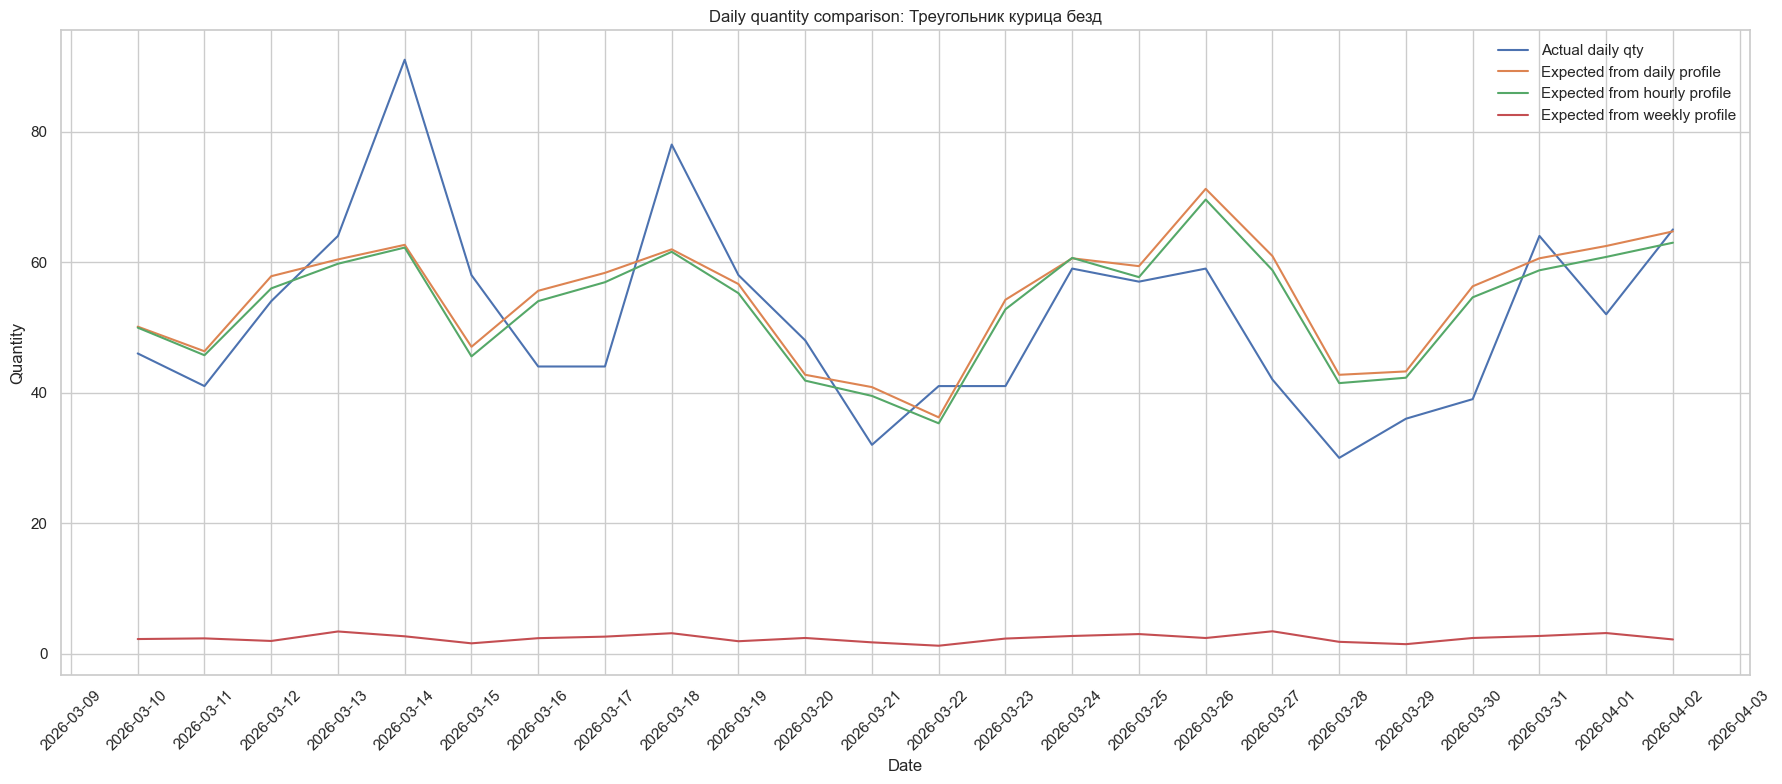

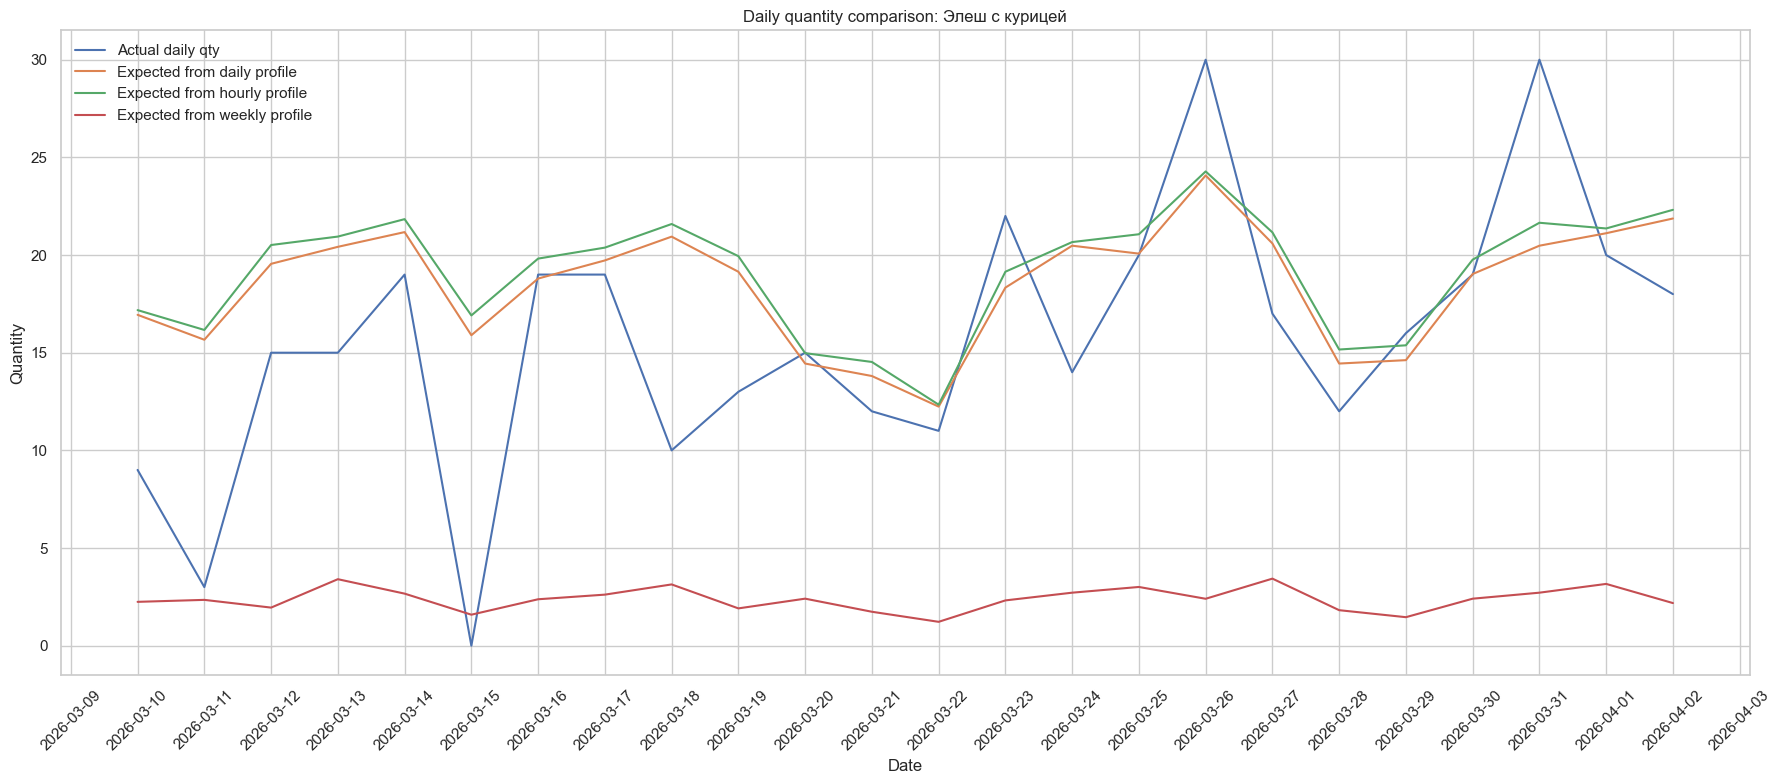

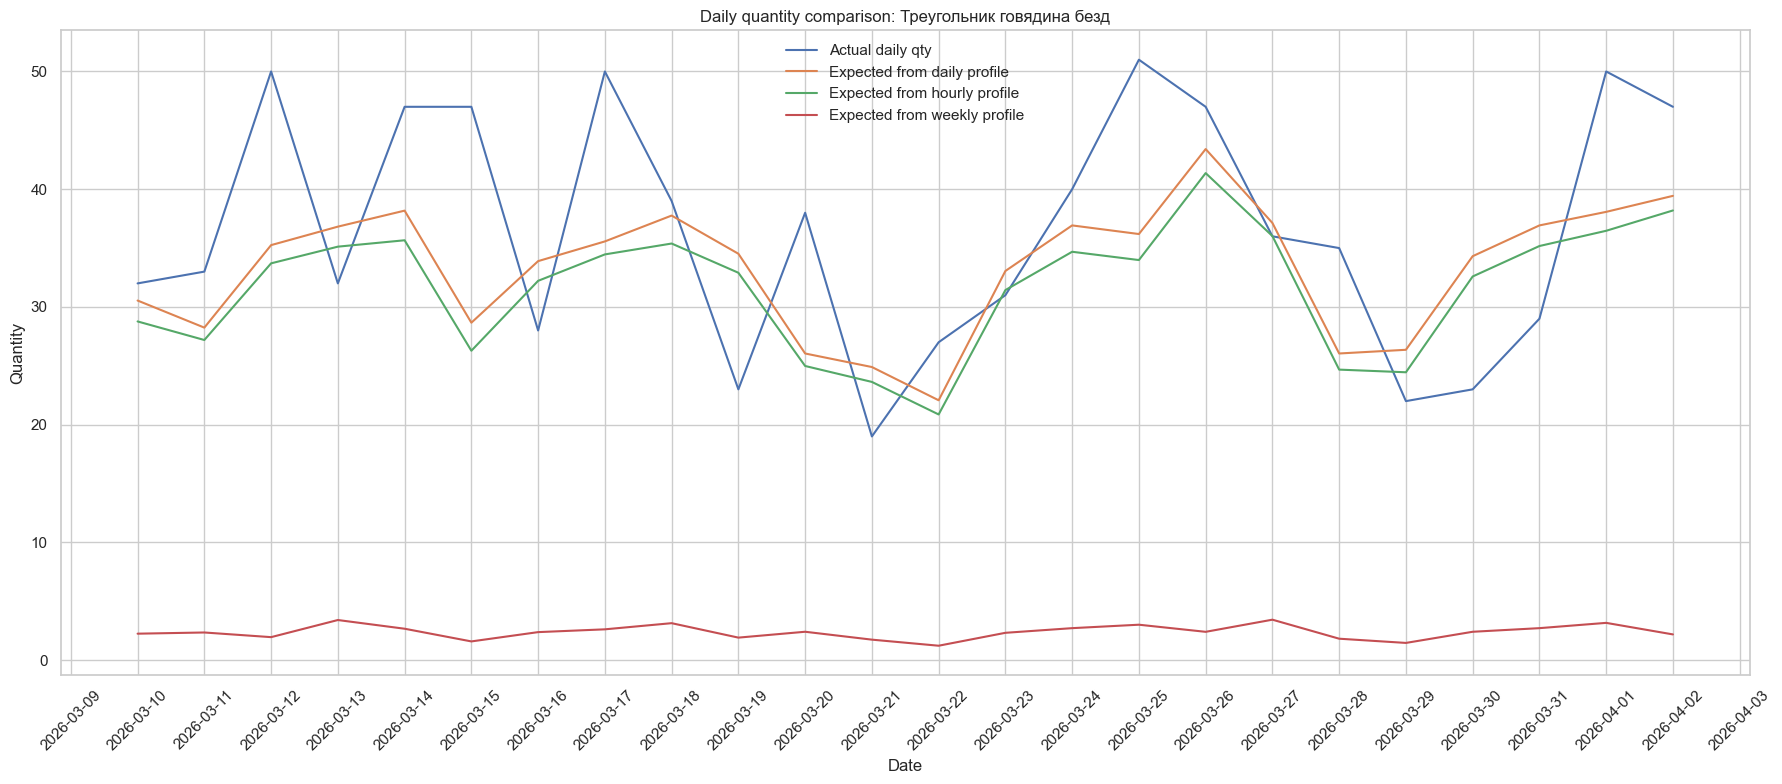

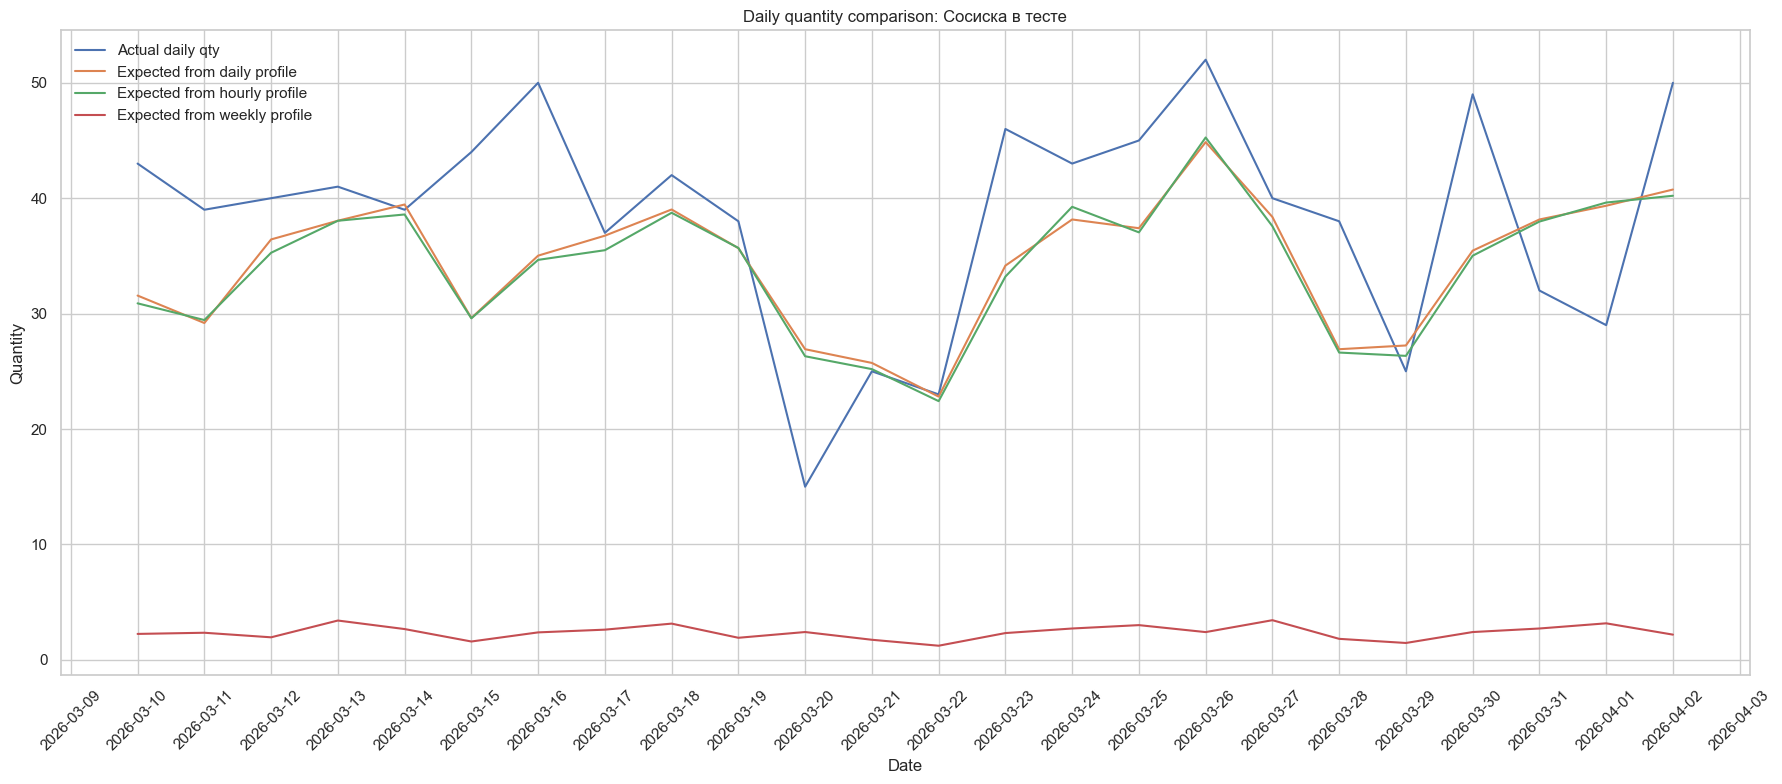

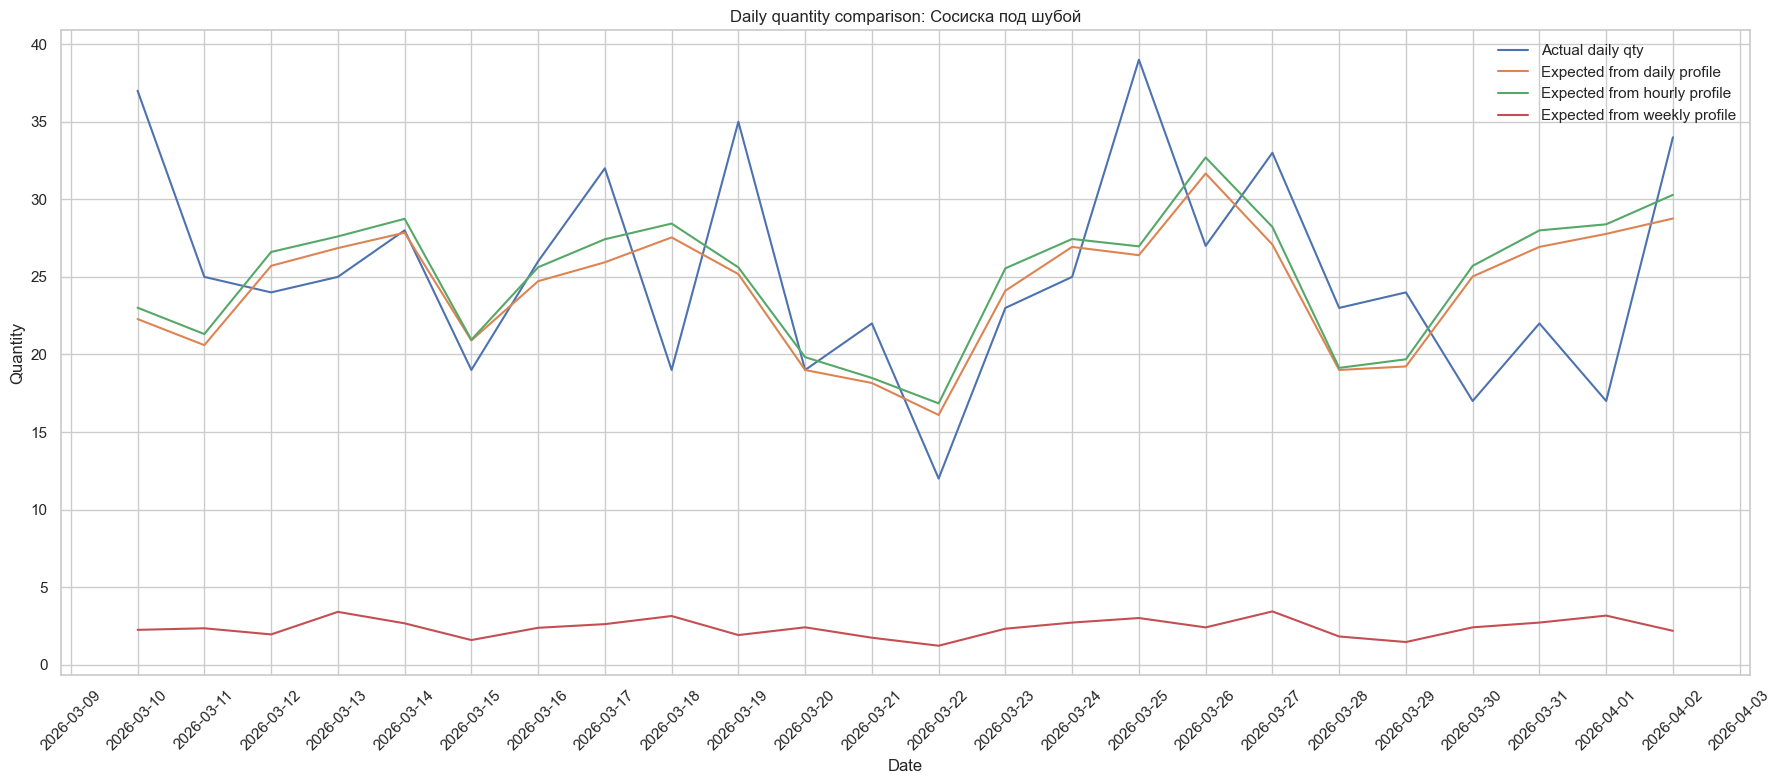

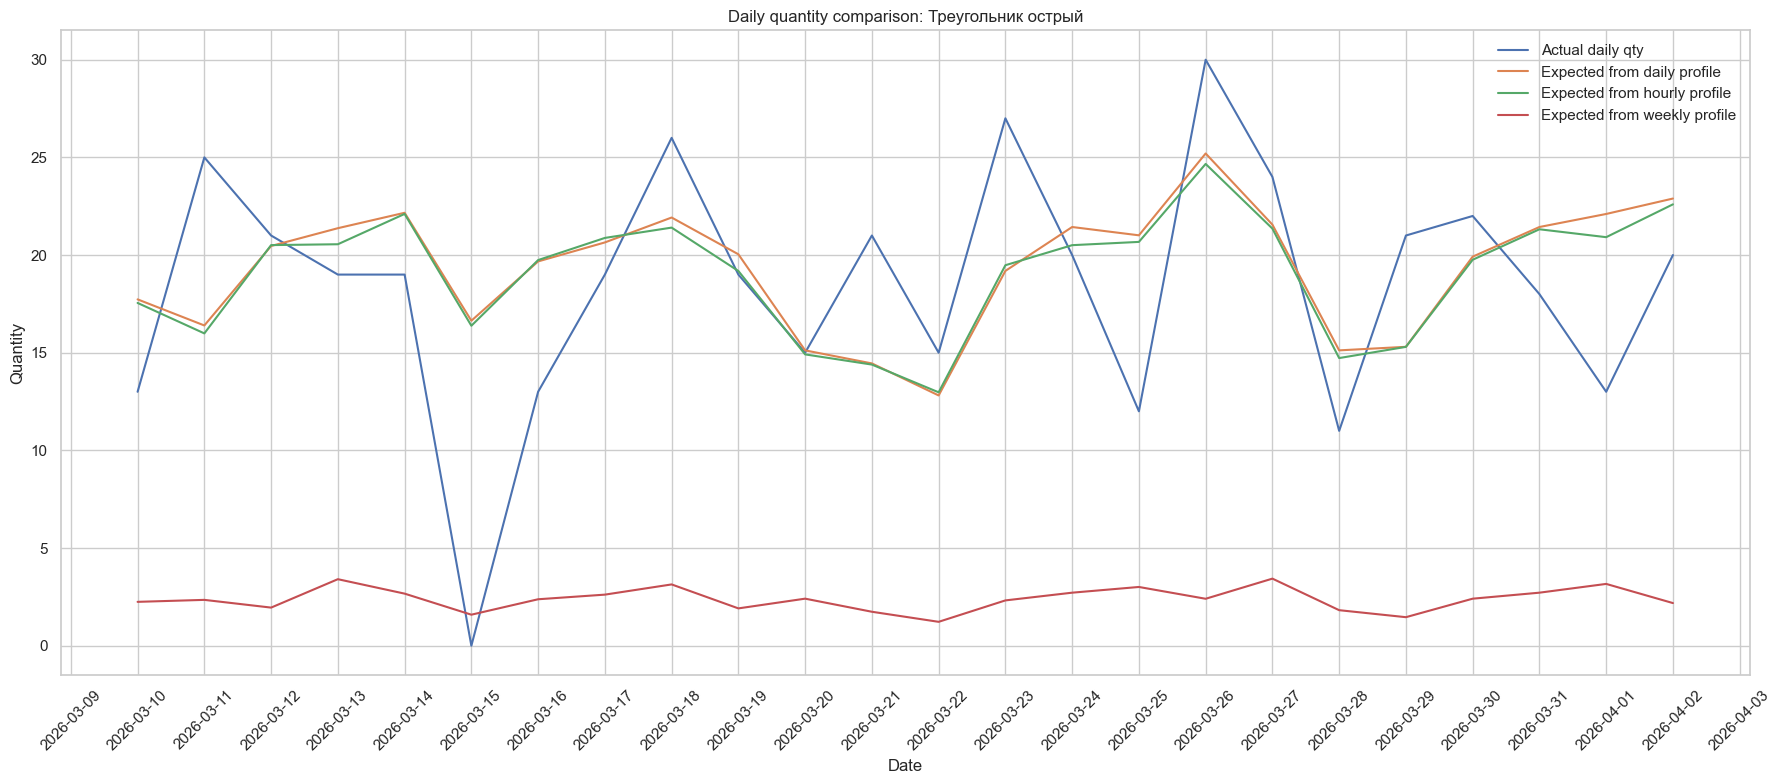

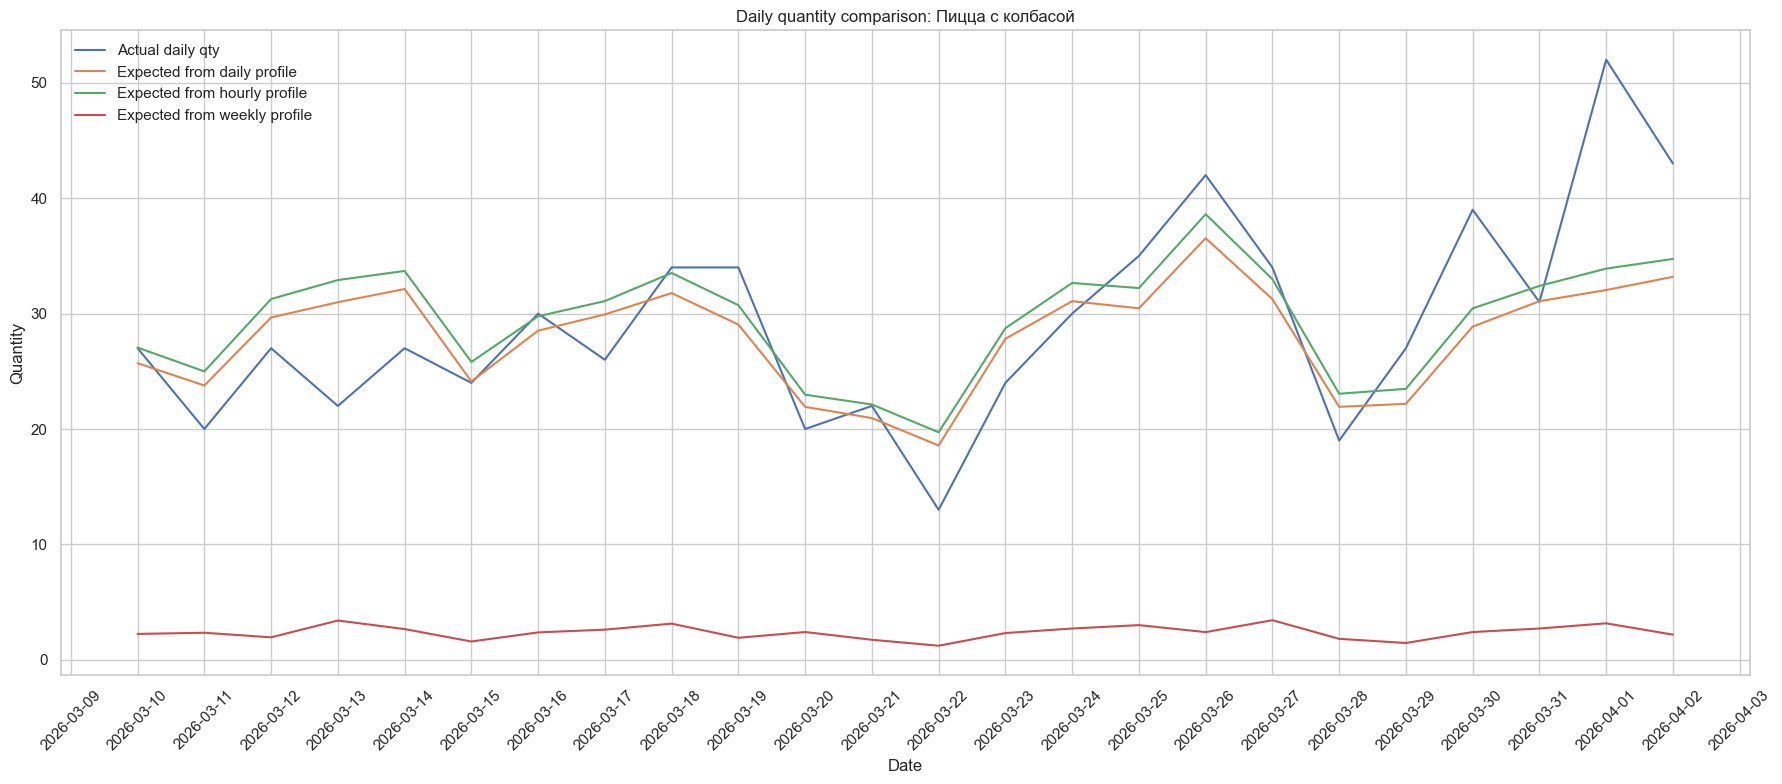

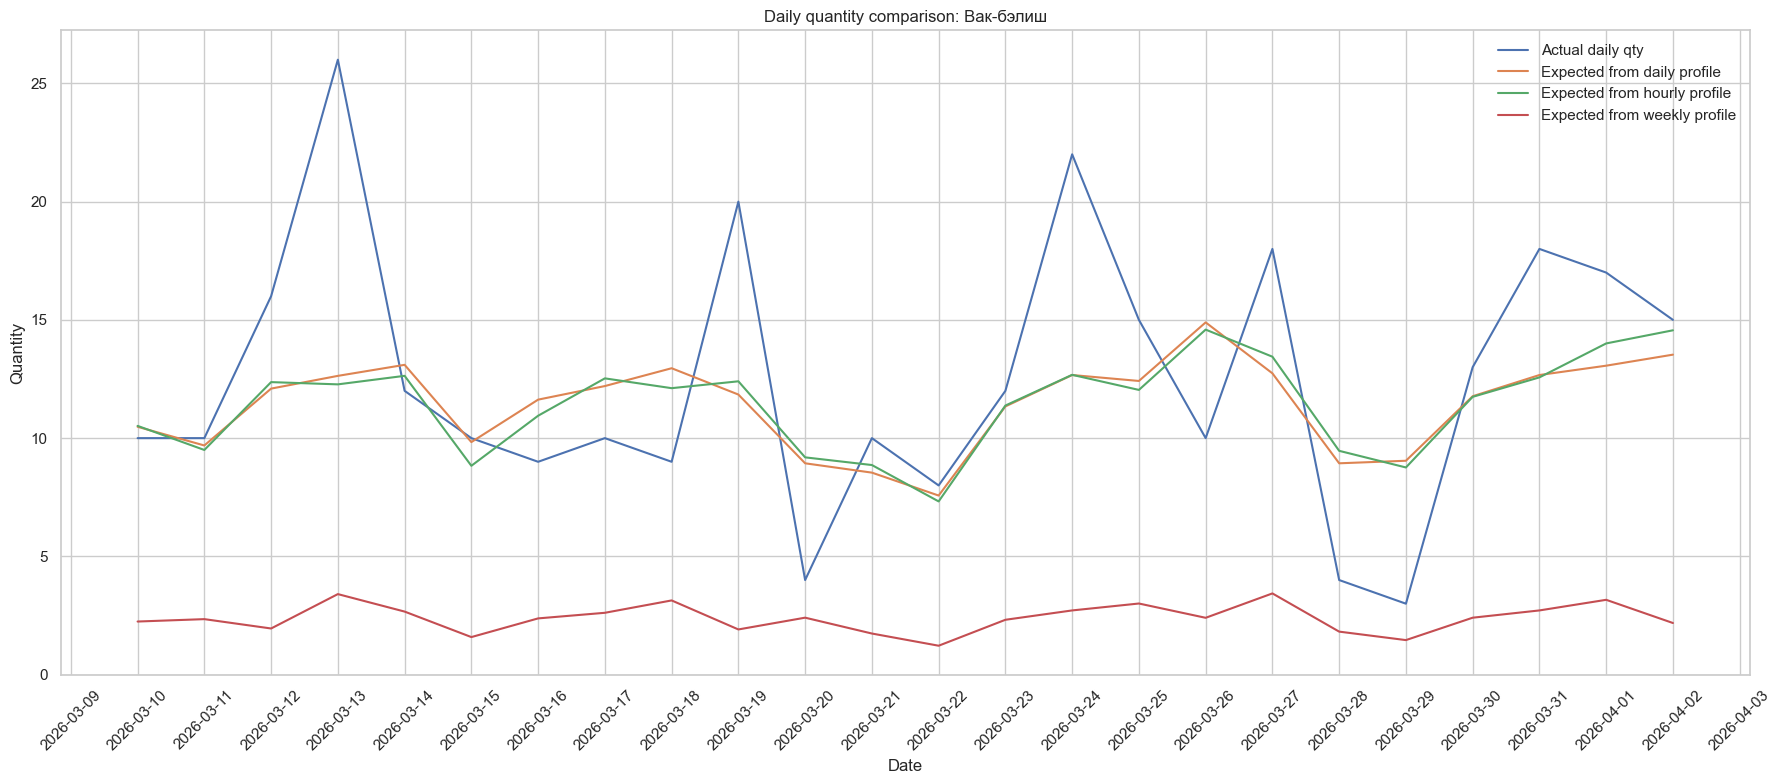

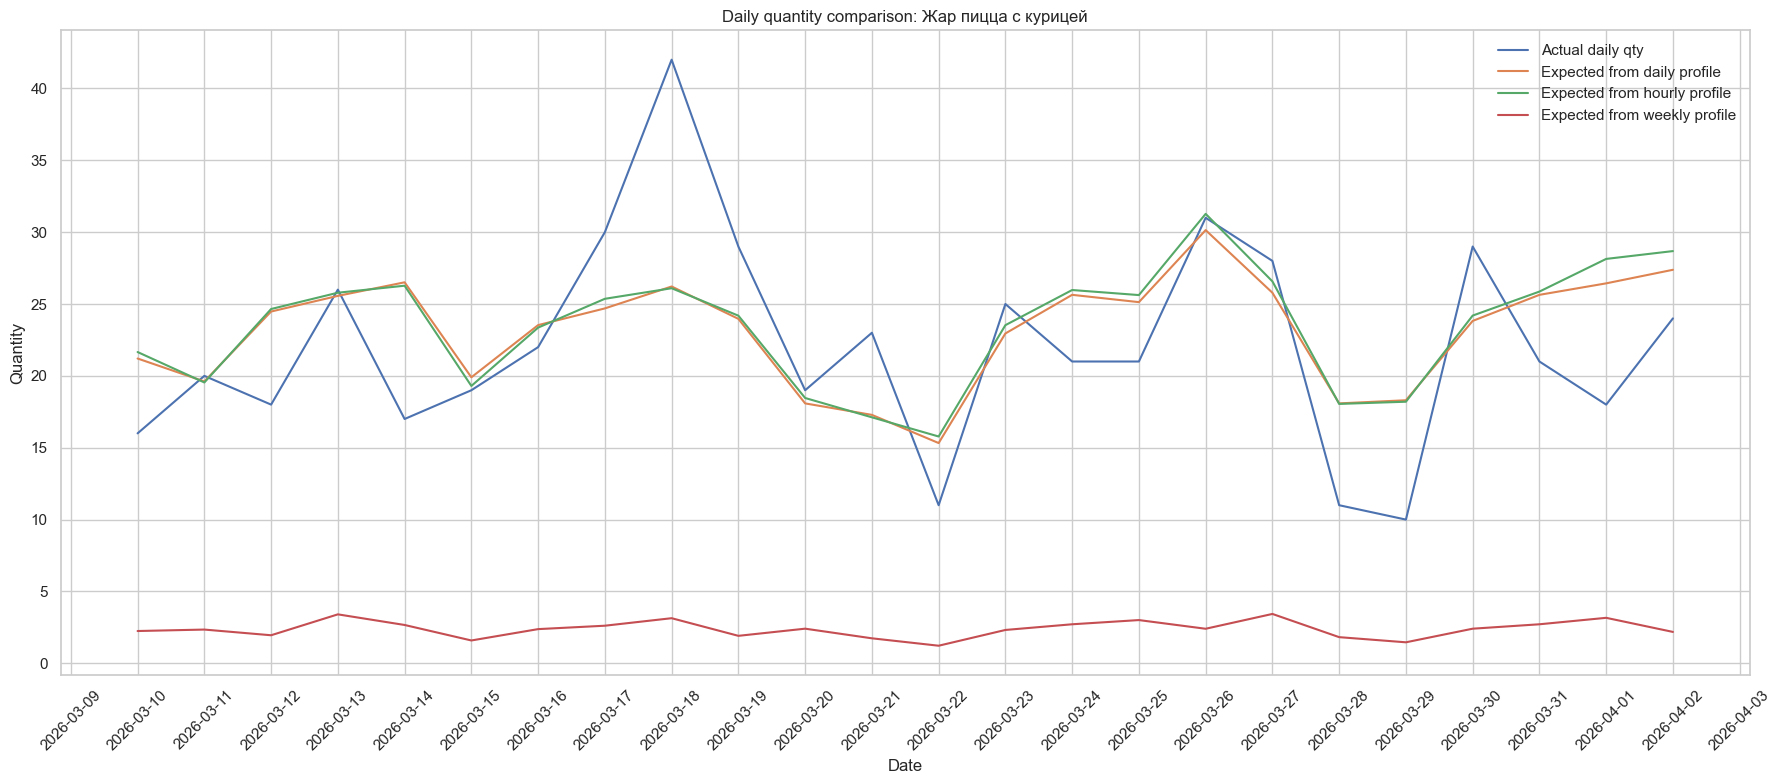

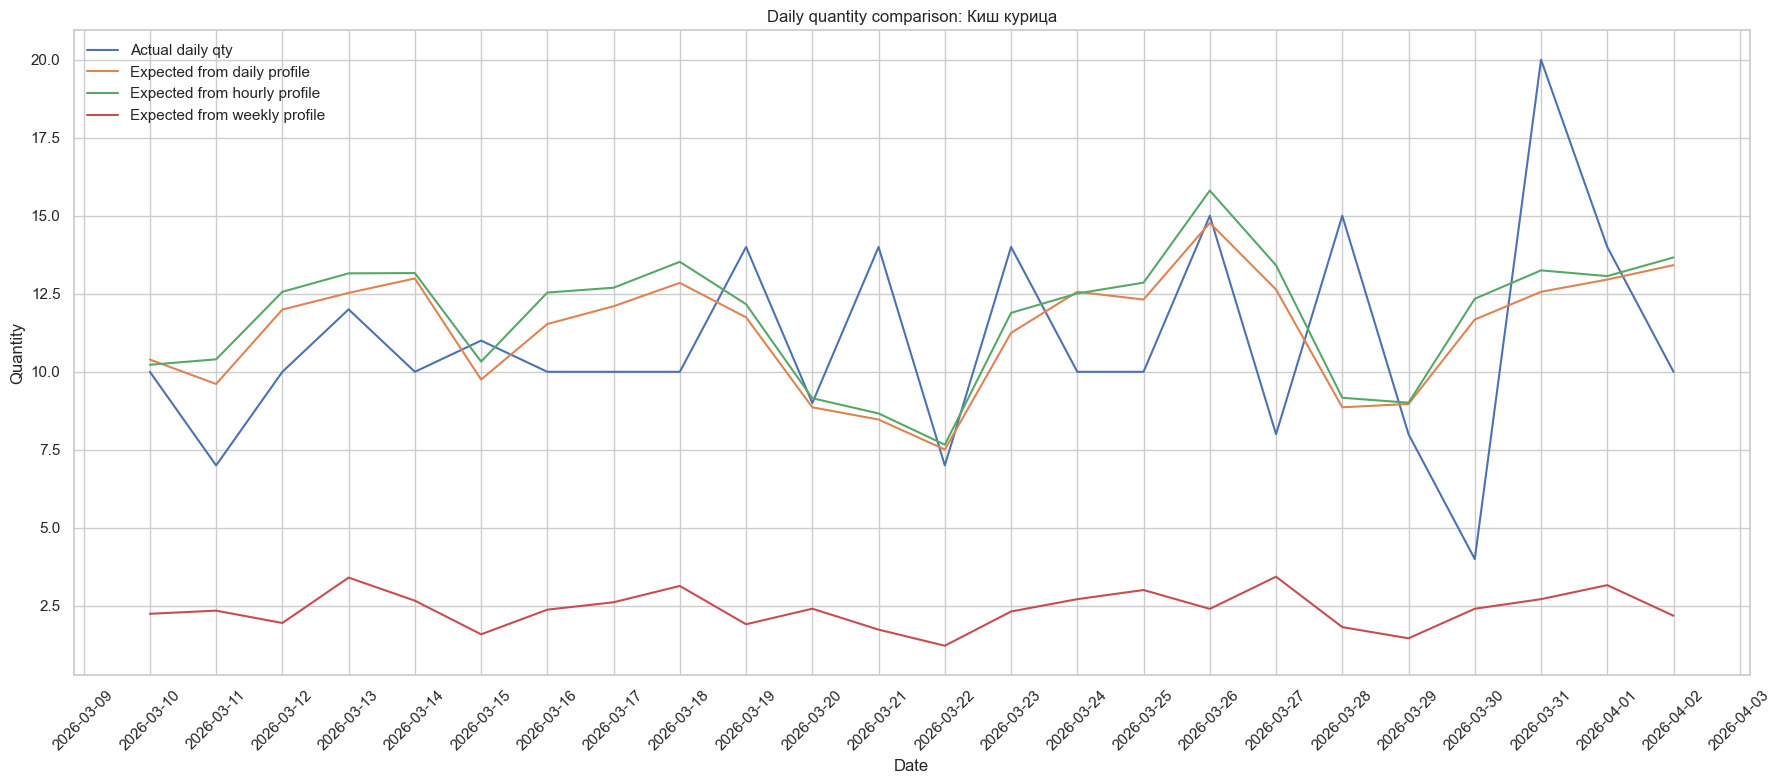

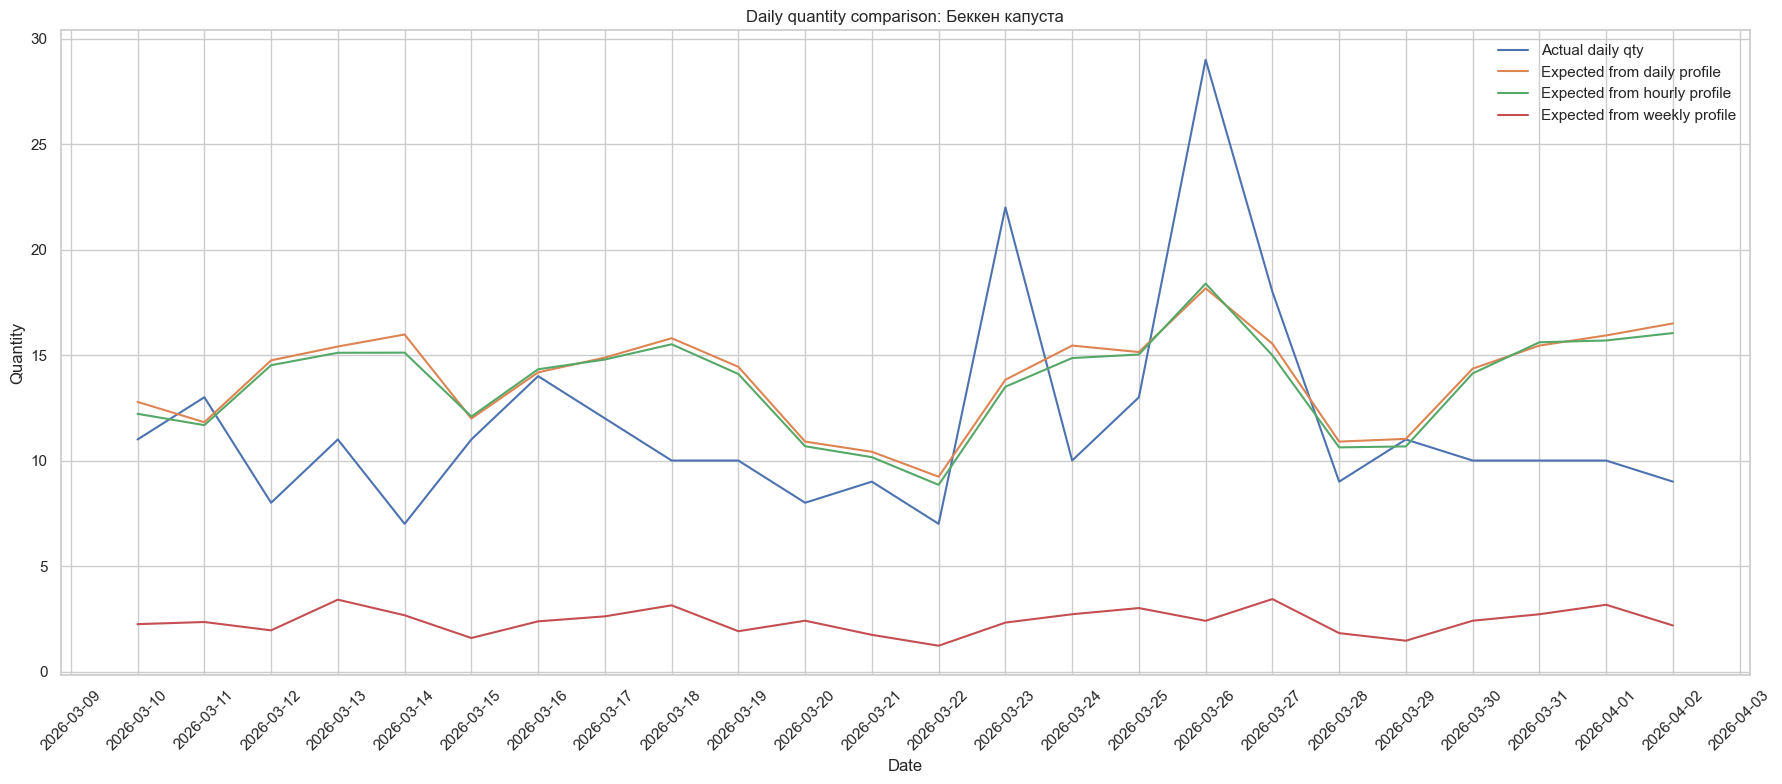

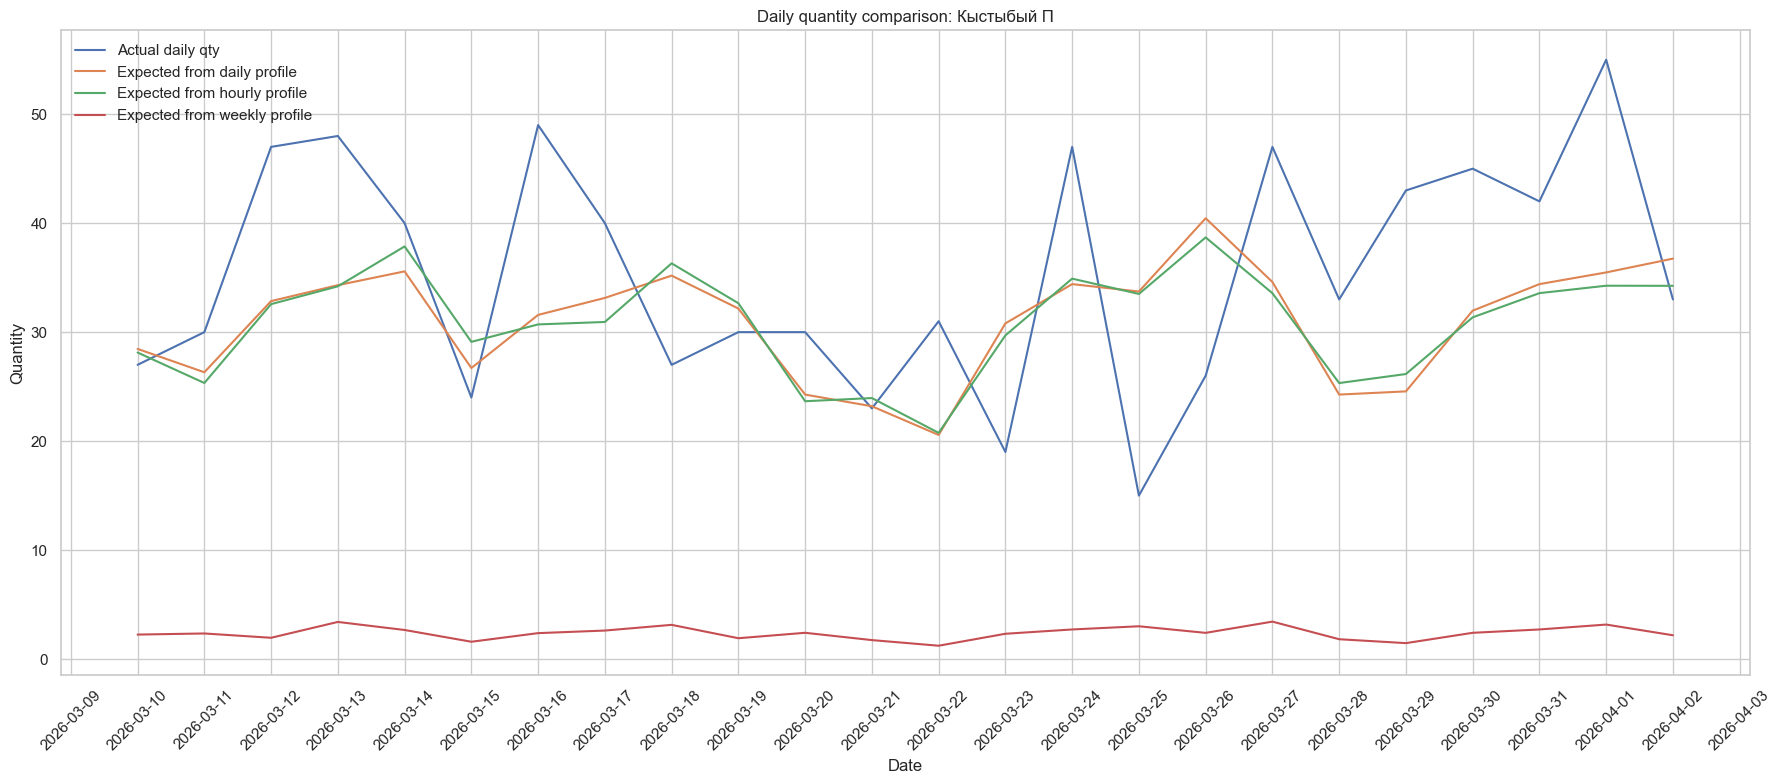

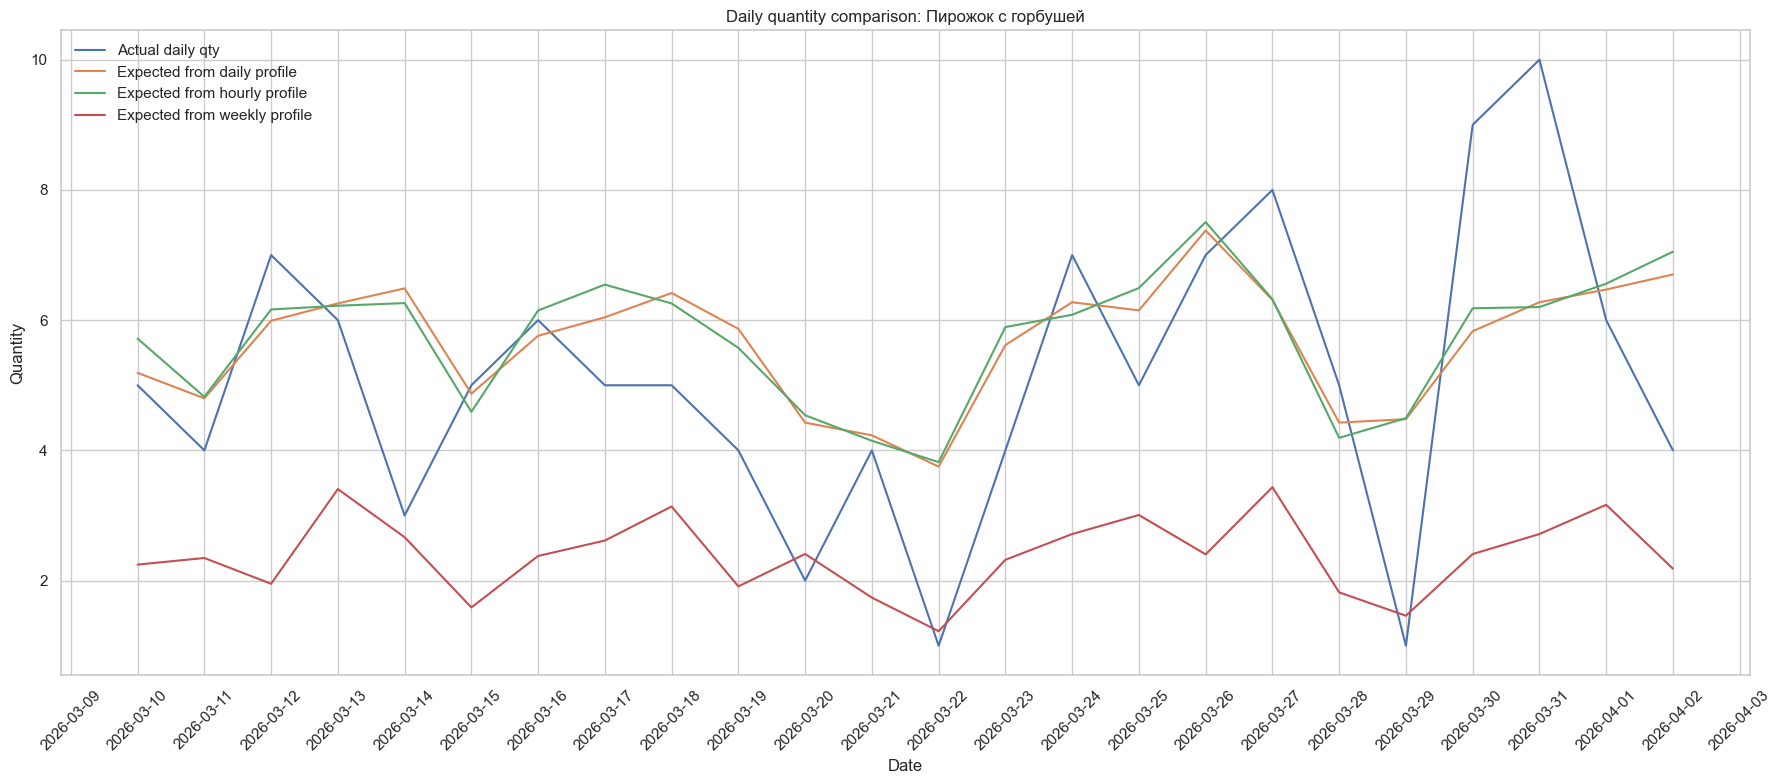

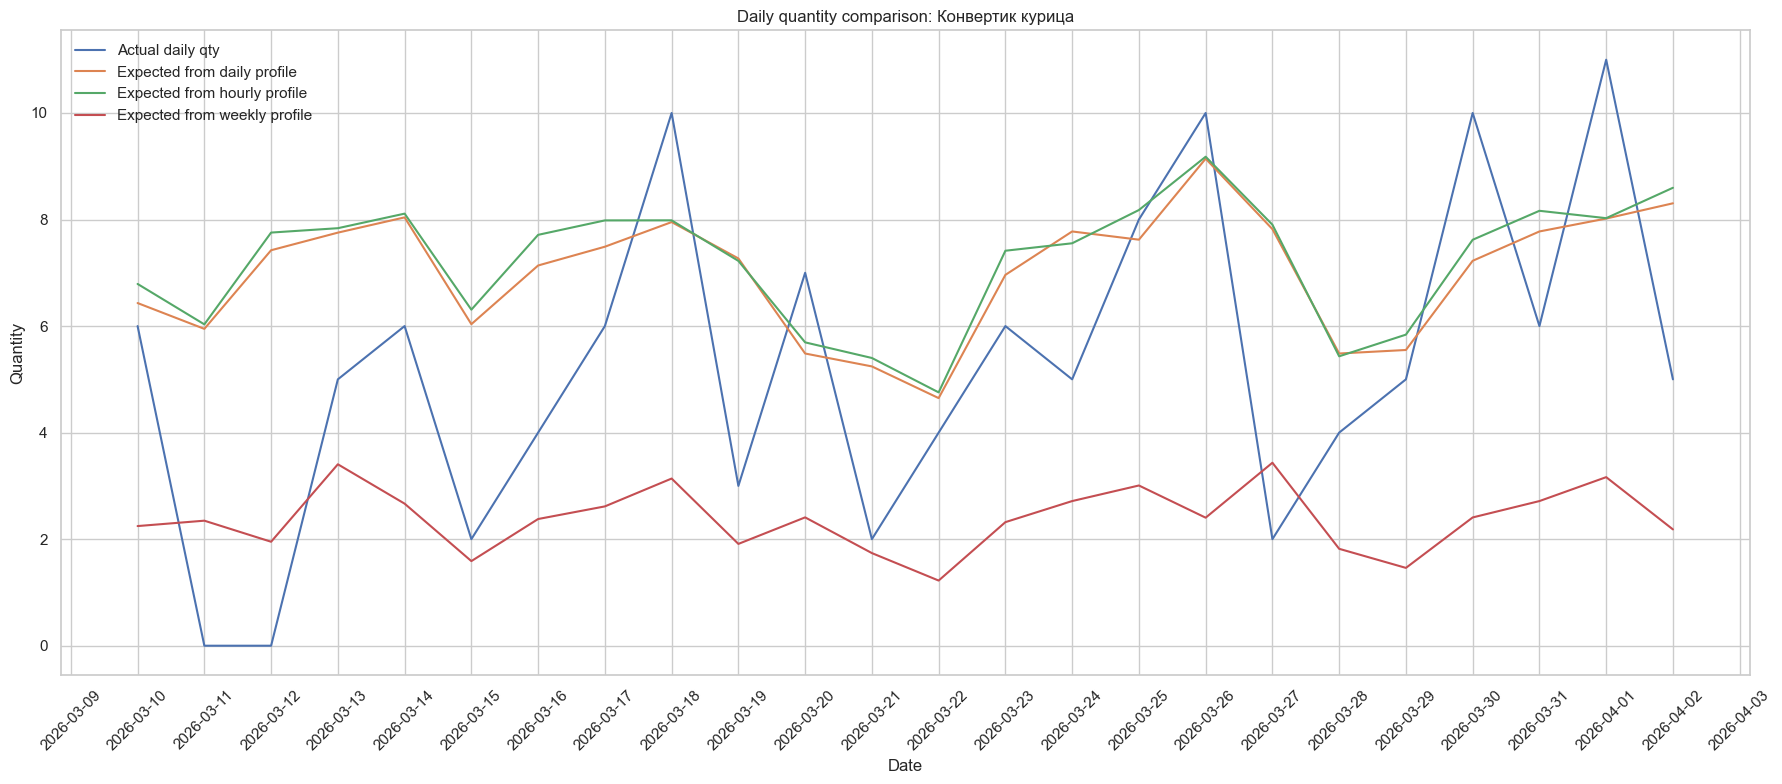

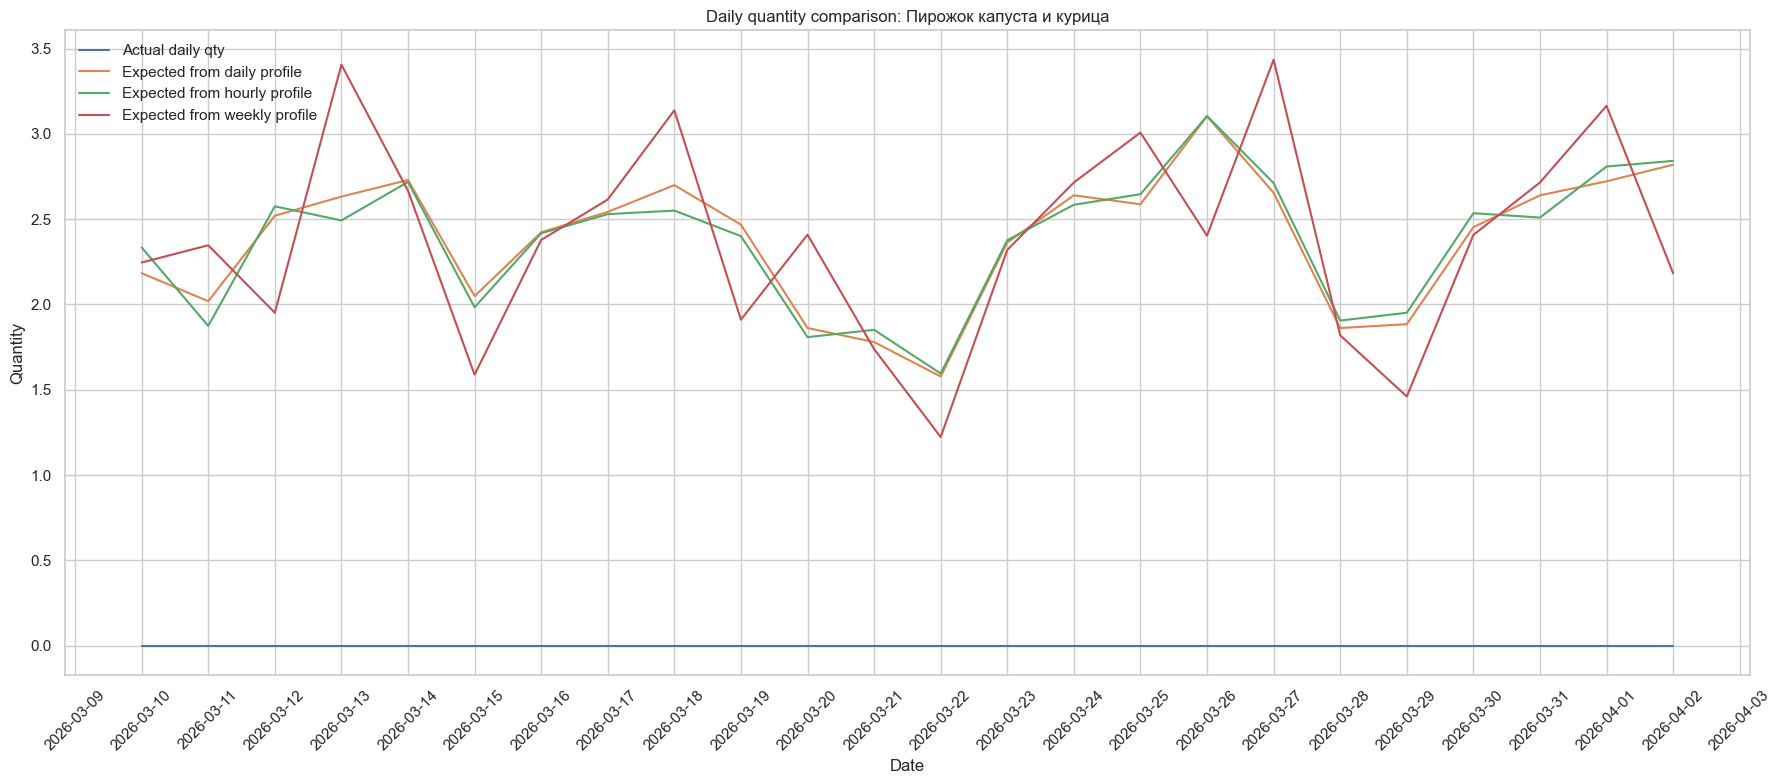

In [280]:
for profile in hourly_profiles:
    for nmk, df in profile.items():
        ploting(df, week_daily_df, nmk)